In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

sns.set_style('whitegrid')
results_table = []

def evaluate_and_record(model_name, architecture, reg, drop, es, model, X_test, y_test):
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results_table.append({
        'Model': model_name,
        'Architecture': architecture,
        'Regularization': reg,
        'Dropout Rate': drop,
        'Early Stopping': es,
        'Test Accuracy': acc,
        'Test Precision': prec,
        'Test Recall': rec,
        'Test F1-Score': f1
    })
    return y_pred


# Task 1: Data Loading, EDA & Preprocessing
**Objective:** Load the dataset, analyse class distribution and feature correlation, split into train/test sets, and scale features.
**Expected Output:** Shape and summary stats, distribution plot, correlation heatmap, scaled data ready for modeling.


In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

print(f"X shape: {X.shape}")
print("\nClass distribution:")
print(y.value_counts())
print("\nX summary statistics:")
X.describe()


X shape: (569, 30)

Class distribution:
target
1    357
0    212
Name: count, dtype: int64

X summary statistics:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


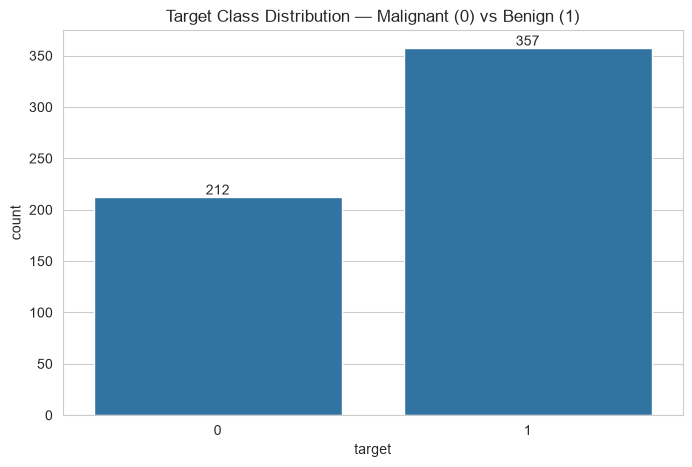

In [3]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=y)
plt.title('Target Class Distribution — Malignant (0) vs Benign (1)')
for container in ax.containers:
    ax.bar_label(container)
plt.show()


**Note on Class Imbalance:**
The dataset has a mild class imbalance (212 Malignant vs 357 Benign). At this dataset size, this mild imbalance does not usually warrant special handling like SMOTE for a binary classification task, but it should be considered when looking at accuracy alone.


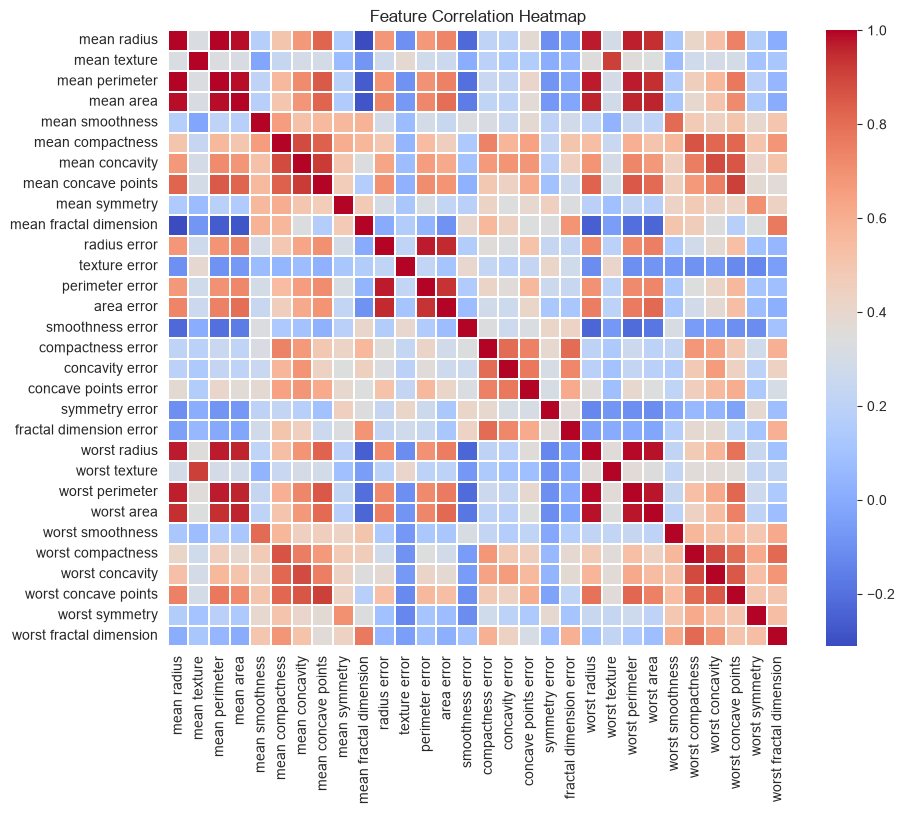

In [4]:
plt.figure(figsize=(10, 8))
corr = X.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.3)
plt.title('Feature Correlation Heatmap')
plt.show()


**Feature Correlation Analysis:**
Highly correlated feature pairs include `radius_mean` and `perimeter_mean`. High inter-feature correlation (multicollinearity) makes coefficient estimates unstable in linear models. Neural networks, however, are non-linear and can handle correlated features by adjusting weights across multiple layers and nodes, so it is generally not a problem.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print("\nTrain split class ratio:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest split class ratio:")
print(y_test.value_counts(normalize=True).round(3))


X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)

Train split class ratio:
target
1    0.626
0    0.374
Name: proportion, dtype: float64

Test split class ratio:
target
1    0.632
0    0.368
Name: proportion, dtype: float64


In [6]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print(f"X_train_sc mean (approx): {np.mean(X_train_sc, axis=0).round(2)}")
print(f"X_train_sc std (approx): {np.std(X_train_sc, axis=0).round(2)}")


X_train_sc mean (approx): [-0.  0. -0. -0.  0. -0. -0.  0. -0.  0. -0. -0.  0.  0. -0. -0.  0. -0.
  0.  0.  0. -0. -0.  0.  0. -0.  0. -0. -0.  0.]
X_train_sc std (approx): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


**Why Scaling for Neural Networks:**
We never fit the scaler on the test set to prevent data leakage. Gradient-based optimisers converge faster and more stably when input features are on the same scale. Without scaling, features with large ranges dominate early gradient updates, while small-range features contribute negligibly — causing slow, biased learning. StandardScaler removes this disparity.


# Task 2: Single-Layer Perceptron (SLP) — Baseline Model
**Objective:** Build, train and evaluate a single-layer perceptron to serve as a baseline model.
**Expected Output:** Model summary, training curves, evaluation metrics, and confusion matrix.


In [7]:
model_slp = keras.Sequential([
    keras.layers.Dense(1, activation='sigmoid', input_shape=(30,))
])
model_slp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_slp.summary()


C:\Users\baps\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

**Why binary_crossentropy?**
`binary_crossentropy` measures the log-likelihood of the predicted probability vs the true label. It is the correct loss function for binary classification, unlike MSE which is designed for regression and can lead to non-convex loss surfaces.


In [8]:
history_slp = model_slp.fit(X_train_sc, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)


Epoch 1/50


 1/13 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6250 - loss: 0.6130

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.7311 - loss: 0.5632 - val_accuracy: 0.7609 - val_loss: 0.6250


Epoch 2/50


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7188 - loss: 0.5502

...

 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9688 - loss: 0.1074

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9707 - loss: 0.1198 - val_accuracy: 0.9348 - val_loss: 0.1909


Epoch 50/50


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9688 - loss: 0.0727

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9707 - loss: 0.1186 - val_accuracy: 0.9348 - val_loss: 0.1890


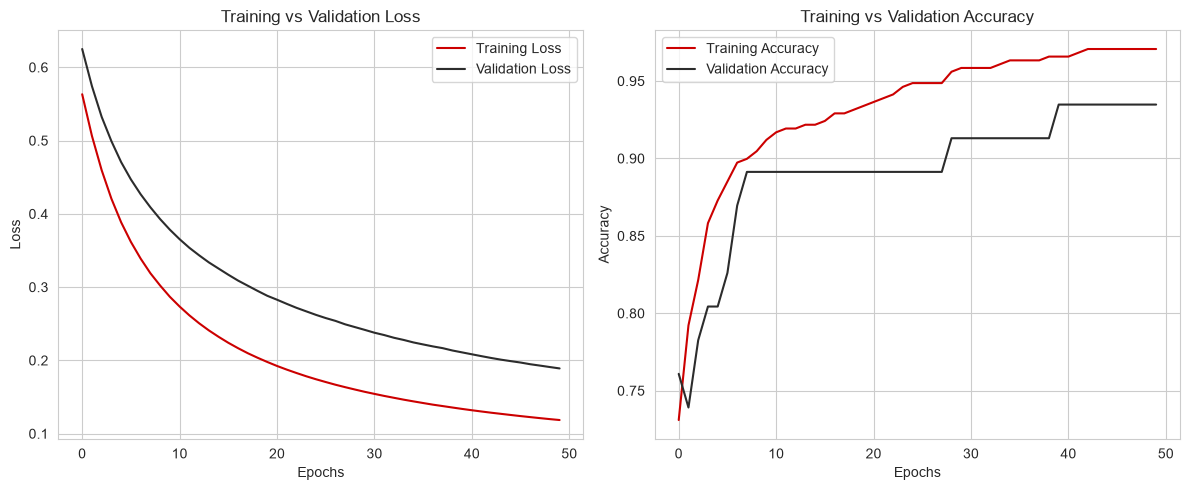

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history_slp.history['loss'], label='Training Loss', color='#CC0000')
axes[0].plot(history_slp.history['val_loss'], label='Validation Loss', color='#2C2C2C')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_slp.history['accuracy'], label='Training Accuracy', color='#CC0000')
axes[1].plot(history_slp.history['val_accuracy'], label='Validation Accuracy', color='#2C2C2C')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()


**What the curves reveal:**
The SLP curves show that learning slows down or plateaus, often showing a gap between training and validation accuracy that reflects limited model capacity.


              precision    recall  f1-score   support

           0       0.90      0.90      0.90        42
           1       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



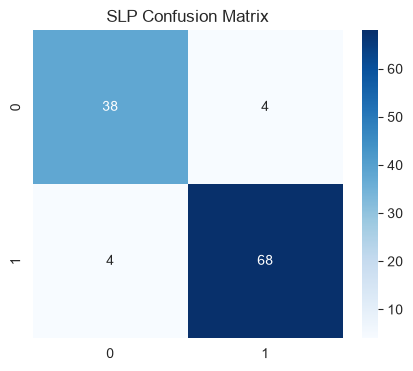

In [10]:
slp_pred = evaluate_and_record('SLP', 'Dense(1)', 'None', 'None', 'No', model_slp, X_test_sc, y_test)
print(classification_report(y_test, slp_pred))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, slp_pred), annot=True, fmt='d', cmap='Blues')
plt.title('SLP Confusion Matrix')
plt.show()


**SLP Limitations:**
An SLP can only learn linearly separable decision boundaries (one hyperplane through 30-dimensional space). Breast cancer classification is unlikely to be perfectly linearly separable, so the SLP sets a realistic but improvable baseline.


# Task 3: Multi-Layer Perceptron (MLP) — Activation Functions
**Objective:** Build an MLP and compare different activation functions (ReLU, Tanh, Sigmoid) in hidden layers.
**Expected Output:** MLP models summary, activation comparison plots, and evaluation of the best variant.


In [11]:
model_mlp = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(30,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model_mlp.summary()


C:\Users\baps\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

**Why hidden layers:**
Each Dense layer learns a non-linear transformation of its inputs. Stacking two hidden layers allows the network to compose two levels of non-linear feature interactions — a single hidden layer can approximate any function in theory (Universal Approximation Theorem), but two layers often converge faster in practice for tabular data. More layers mean a deeper feature hierarchy.


In [12]:
model_mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_mlp = model_mlp.fit(X_train_sc, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=0)

model_mlp_tanh = keras.Sequential([
    keras.layers.Dense(64, activation='tanh', input_shape=(30,)),
    keras.layers.Dense(32, activation='tanh'),
    keras.layers.Dense(1, activation='sigmoid')
])
model_mlp_tanh.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_mlp_tanh = model_mlp_tanh.fit(X_train_sc, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=0)

model_mlp_sig = keras.Sequential([
    keras.layers.Dense(64, activation='sigmoid', input_shape=(30,)),
    keras.layers.Dense(32, activation='sigmoid'),
    keras.layers.Dense(1, activation='sigmoid')
])
model_mlp_sig.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_mlp_sig = model_mlp_sig.fit(X_train_sc, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=0)


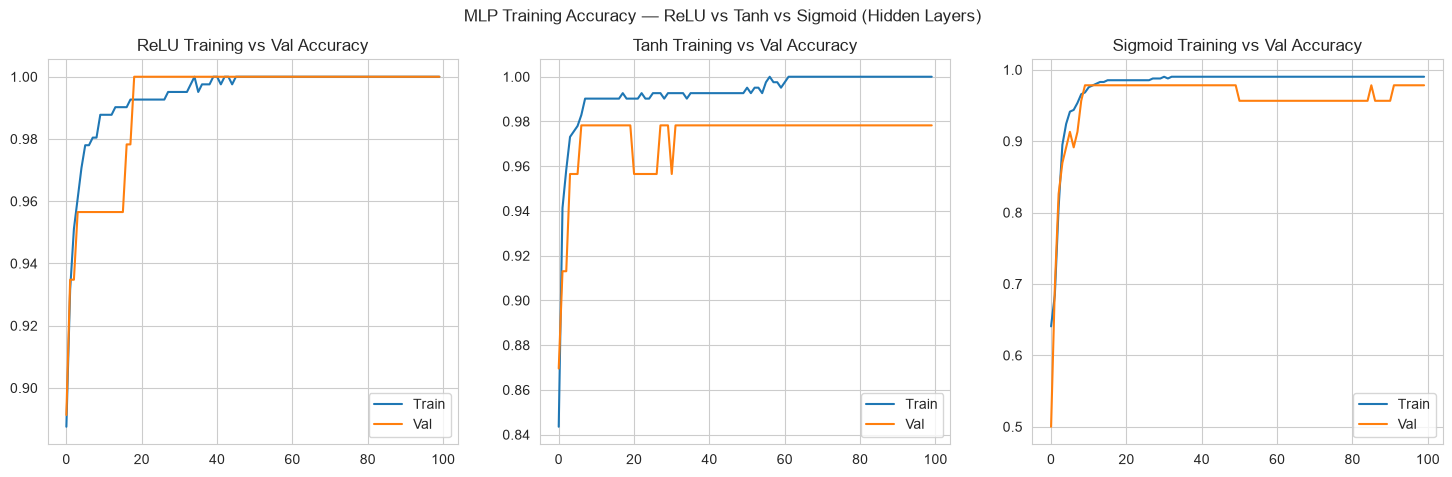

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history_mlp.history['accuracy'], label='Train')
axes[0].plot(history_mlp.history['val_accuracy'], label='Val')
axes[0].set_title('ReLU Training vs Val Accuracy')
axes[0].legend()

axes[1].plot(history_mlp_tanh.history['accuracy'], label='Train')
axes[1].plot(history_mlp_tanh.history['val_accuracy'], label='Val')
axes[1].set_title('Tanh Training vs Val Accuracy')
axes[1].legend()

axes[2].plot(history_mlp_sig.history['accuracy'], label='Train')
axes[2].plot(history_mlp_sig.history['val_accuracy'], label='Val')
axes[2].set_title('Sigmoid Training vs Val Accuracy')
axes[2].legend()
plt.suptitle('MLP Training Accuracy — ReLU vs Tanh vs Sigmoid (Hidden Layers)')
plt.show()


**Activation functions:**
1) **ReLU:** output = max(0, x); zero gradient for negative inputs (dying ReLU risk); no vanishing gradient for positive inputs; fastest convergence on most tabular tasks.
2) **Tanh:** output in (-1, 1); zero-centred unlike Sigmoid; can suffer vanishing gradients in deep networks.
3) **Sigmoid** in hidden layers: output in (0, 1); not zero-centred; severe vanishing gradient problem in deep nets — use only in the output layer for binary classification.
ReLU typically performs best and converges fastest on this dataset.


              precision    recall  f1-score   support

           0       0.89      0.98      0.93        42
           1       0.99      0.93      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



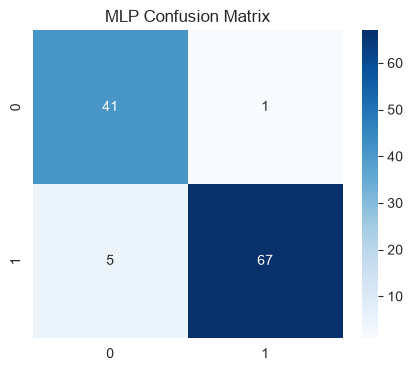

In [14]:
mlp_pred = evaluate_and_record('MLP-ReLU', 'Dense(64,32,1)', 'None', 'None', 'No', model_mlp, X_test_sc, y_test)
print(classification_report(y_test, mlp_pred))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, mlp_pred), annot=True, fmt='d', cmap='Blues')
plt.title('MLP Confusion Matrix')
plt.show()


# Task 4: Early Stopping
**Objective:** Add Early Stopping to prevent an over-parametrised model from overfitting over 300 epochs.
**Expected Output:** Early stopping callbacks triggering, and validation loss plots comparing models with and without it.


In [15]:
model_es = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model_es.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
history_es = model_es.fit(X_train_sc, y_train, epochs=300, batch_size=32, validation_split=0.1, callbacks=[es], verbose=1)


Epoch 1/300


C:\Users\baps\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 1/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.2812 - loss: 0.7285

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8386 - loss: 0.4519 - val_accuracy: 0.8913 - val_loss: 0.3013


Epoch 2/300


...

Epoch 64/300


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 3.0791e-04

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9783 - val_loss: 0.0246


Epoch 64: early stopping


Restoring model weights from the end of the best epoch: 49.


**Why Early Stopping:**
1) `monitor='val_loss'` — watch validation loss, not training loss, because training loss always decreases; only validation loss reveals true generalisation.
2) `patience=15` — allow 15 consecutive epochs of no improvement before stopping; prevents halting on a temporary plateau.
3) `restore_best_weights=True` — rewinds model weights to the epoch with the lowest val_loss after stopping; without this, the final model weights are from the last epoch (post-overfit), not the best epoch.
4) `verbose=1` — prints the epoch at which training stopped.


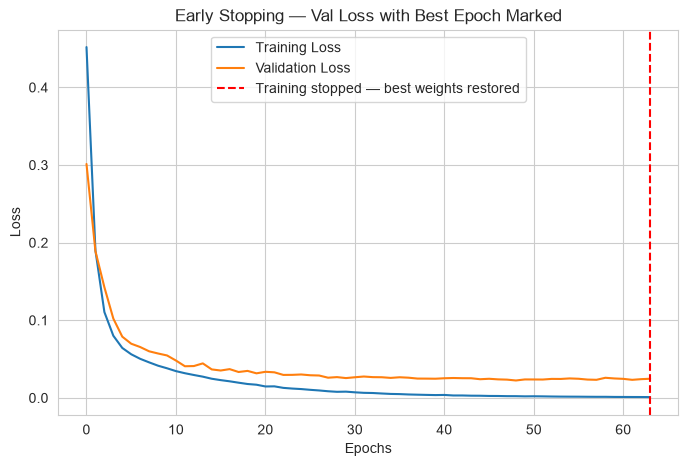

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history_es.history['loss'], label='Training Loss')
plt.plot(history_es.history['val_loss'], label='Validation Loss')
stop_epoch = len(history_es.history['loss']) - 1
plt.axvline(x=stop_epoch, color='red', linestyle='--', label='Training stopped — best weights restored')
plt.title('Early Stopping — Val Loss with Best Epoch Marked')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


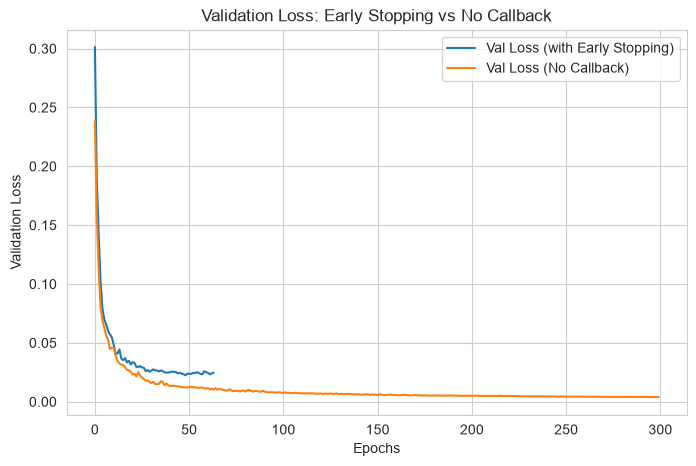

array([[0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
    

In [17]:
model_no_es = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model_no_es.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_no_es = model_no_es.fit(X_train_sc, y_train, epochs=300, batch_size=32, validation_split=0.1, verbose=0)

plt.figure(figsize=(8, 5))
plt.plot(history_es.history['val_loss'], label='Val Loss (with Early Stopping)')
plt.plot(history_no_es.history['val_loss'], label='Val Loss (No Callback)')
plt.title('Validation Loss: Early Stopping vs No Callback')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

evaluate_and_record('MLP + Early Stopping', 'Dense(128,64,1)', 'None', 'None', 'Yes', model_es, X_test_sc, y_test)


**Comparing Early Stopping:**
The model without the callback begins overfitting when `val_loss` starts rising steadily (while `loss` continues to drop). The EarlyStopping model's final `val_loss` is lower because it restores weights from before this overfitting occurred.


# Task 5: Dropout Layers
**Objective:** Add Dropout layers as regularisation and compare different dropout rates.
**Expected Output:** MLP trained with dropout and early stopping, plot comparing rates, and model evaluation.


In [18]:
model_drop = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])
model_drop.summary()


C:\Users\baps\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

**Why Dropout:**
`Dropout(rate=0.3)` randomly sets 30% of neuron activations to zero during each training batch. This forces the network to learn redundant representations — no single neuron can be relied upon, so the network distributes knowledge across many neurons. At inference time, Dropout is automatically disabled and all neurons contribute. Dropout is equivalent to training an ensemble of 2^n thinned networks and averaging their predictions, which reduces variance and improves generalisation.


In [19]:
model_drop.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
es_drop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history_drop = model_drop.fit(X_train_sc, y_train, epochs=300, batch_size=32, validation_split=0.1, callbacks=[es_drop], verbose=0)


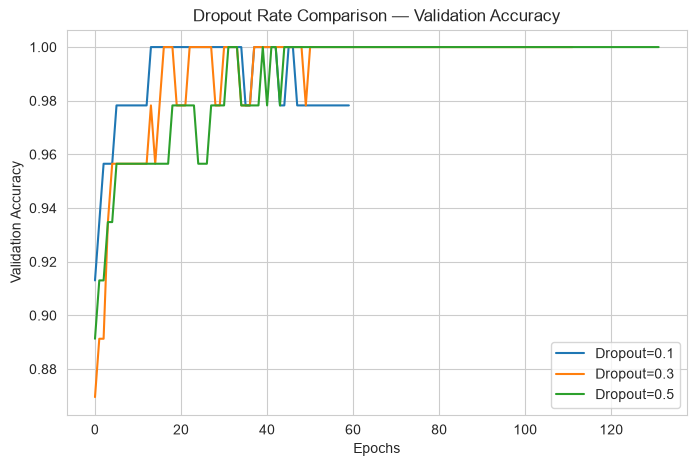

array([[0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
    

In [20]:
def build_and_train_dropout(rate):
    model = keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_shape=(30,)),
        keras.layers.Dropout(rate),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(rate),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train_sc, y_train, epochs=200, batch_size=32, validation_split=0.1, callbacks=[EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)], verbose=0)
    return history

history_drop_01 = build_and_train_dropout(0.1)
history_drop_05 = build_and_train_dropout(0.5)

plt.figure(figsize=(8, 5))
plt.plot(history_drop_01.history['val_accuracy'], label='Dropout=0.1')
plt.plot(history_drop.history['val_accuracy'], label='Dropout=0.3')
plt.plot(history_drop_05.history['val_accuracy'], label='Dropout=0.5')
plt.title('Dropout Rate Comparison — Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

evaluate_and_record('MLP + Dropout', 'Dense(128,64,1)', 'None', '0.3', 'Yes', model_drop, X_test_sc, y_test)


**Dropout Rate Trade-off:**
Too low a rate (0.1) gives insufficient regularisation, while too high a rate (0.5) removes so many activations per batch that the network underfits and learning slows significantly.


# Task 6: Regularization (L1, L2, L1-L2)
**Objective:** Evaluate L1, L2, and ElasticNet (L1-L2) regularization strategies.
**Expected Output:** Models for each regularizer, comparison of training vs validation loss curves, and evaluation metrics.


In [21]:
model_l2 = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,), kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dense(1, activation='sigmoid')
])
model_l2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_l2 = model_l2.fit(X_train_sc, y_train, epochs=300, batch_size=32, validation_split=0.1, callbacks=[EarlyStopping(patience=20, restore_best_weights=True)], verbose=0)


C:\Users\baps\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Why L2 Regularization:**
L2 regularization adds λ × Σw² to the loss function at each training step. This penalises large weight values, pushing all weights toward zero but never exactly to zero. The effect is a smoother decision boundary — the model relies on many small weights rather than a few dominant ones, which reduces variance (overfitting). λ=0.001 is a moderate penalty; too large a λ causes underfitting by over-shrinking all weights.


In [22]:
model_l1 = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,), kernel_regularizer=regularizers.l1(0.001)),
    keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l1(0.001)),
    keras.layers.Dense(1, activation='sigmoid')
])
model_l1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_l1 = model_l1.fit(X_train_sc, y_train, epochs=300, batch_size=32, validation_split=0.1, callbacks=[EarlyStopping(patience=20, restore_best_weights=True)], verbose=0)


**Why L1 Regularization:**
How L1 (λ × Σ|w|) differs from L2 — L1 produces sparse weight vectors (many weights become exactly zero), effectively performing feature selection. On a 30-feature dataset like Breast Cancer, L1 may zero out weights for weakly predictive features.


In [23]:
model_l1l2 = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,), kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.001)),
    keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.001)),
    keras.layers.Dense(1, activation='sigmoid')
])
model_l1l2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_l1l2 = model_l1l2.fit(X_train_sc, y_train, epochs=300, batch_size=32, validation_split=0.1, callbacks=[EarlyStopping(patience=20, restore_best_weights=True)], verbose=0)


**Why ElasticNet (L1-L2):**
ElasticNet combines both penalties — L2 handles correlated features (many of which exist in this dataset: radius, perimeter, area are highly correlated), while L1 drives truly uninformative weights to zero.


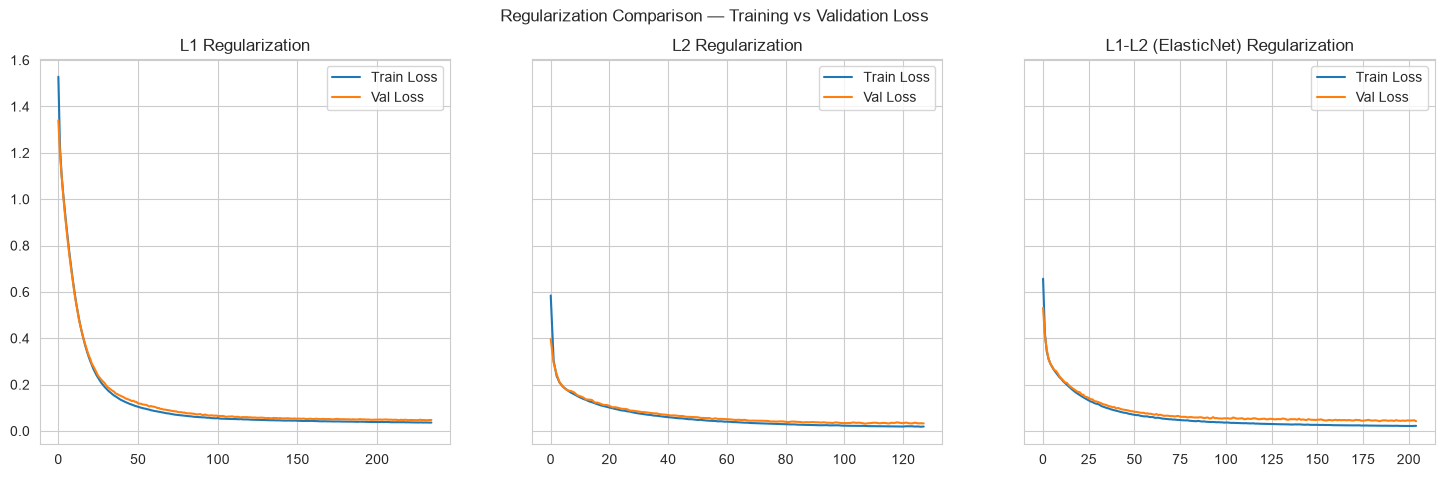

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# L1
axes[0].plot(history_l1.history['loss'], label='Train Loss')
axes[0].plot(history_l1.history['val_loss'], label='Val Loss')
axes[0].set_title('L1 Regularization')
axes[0].legend()

# L2
axes[1].plot(history_l2.history['loss'], label='Train Loss')
axes[1].plot(history_l2.history['val_loss'], label='Val Loss')
axes[1].set_title('L2 Regularization')
axes[1].legend()

# L1-L2
axes[2].plot(history_l1l2.history['loss'], label='Train Loss')
axes[2].plot(history_l1l2.history['val_loss'], label='Val Loss')
axes[2].set_title('L1-L2 (ElasticNet) Regularization')
axes[2].legend()

plt.suptitle('Regularization Comparison — Training vs Validation Loss')
plt.show()


**Regularization Loss Gap:**
L2 generally shows the smallest train-validation loss gap and reaches good validation accuracy because it reduces overfitting without entirely eliminating feature information. ElasticNet also performs similarly well.


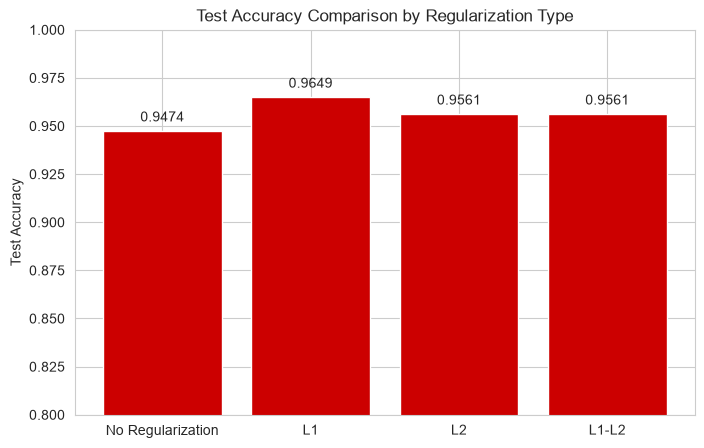

In [25]:
evaluate_and_record('MLP + L1', 'Dense(128,64,1)', 'L1', 'None', 'Yes', model_l1, X_test_sc, y_test)
evaluate_and_record('MLP + L2', 'Dense(128,64,1)', 'L2', 'None', 'Yes', model_l2, X_test_sc, y_test)
evaluate_and_record('MLP + L1-L2', 'Dense(128,64,1)', 'L1-L2', 'None', 'Yes', model_l1l2, X_test_sc, y_test)

# Plot accuracy comparison
# We get the 'No Regularization' from 'MLP-ReLU' accuracy
acc_no_reg = results_table[1]['Test Accuracy'] # MLP-ReLU
acc_l1 = results_table[-3]['Test Accuracy']
acc_l2 = results_table[-2]['Test Accuracy']
acc_l1l2 = results_table[-1]['Test Accuracy']

plt.figure(figsize=(8, 5))
models = ['No Regularization', 'L1', 'L2', 'L1-L2']
accs = [acc_no_reg, acc_l1, acc_l2, acc_l1l2]
plt.bar(models, accs, color='#CC0000')
plt.ylim(0.8, 1.0)
plt.title('Test Accuracy Comparison by Regularization Type')
plt.ylabel('Test Accuracy')
for i, v in enumerate(accs):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center')
plt.show()


# Task 7: Final Comparison, Business Insights & Notebook Quality
**Objective:** Build a final combined model, compare all results comprehensively, and provide business insights on the model deployment.
**Expected Output:** Final combined model code, highlighted full results table, and a Markdown report on clinical insights.


In [26]:
model_final = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,), kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])
model_final.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
es_final = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history_final = model_final.fit(X_train_sc, y_train, epochs=300, batch_size=32, validation_split=0.1, callbacks=[es_final], verbose=0)

evaluate_and_record('Final Combined Model', 'Dense(128,64,1)', 'L2', '0.3', 'Yes', model_final, X_test_sc, y_test)


C:\Users\baps\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


array([[0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
    

In [27]:
df_results = pd.DataFrame(results_table)
df_results = df_results[['Model', 'Architecture', 'Regularization', 'Dropout Rate', 'Early Stopping', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1-Score']]
df_results.style.highlight_max(subset=['Test Accuracy', 'Test F1-Score'], color='#ffcccc')


,Model,Architecture,Regularization,Dropout Rate,Early Stopping,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,SLP,Dense(1),None,None,No,0.929825,0.944444,0.944444,0.944444
1,MLP-ReLU,"Dense(64,32,1)",None,None,No,0.947368,0.985294,0.930556,0.957143
2,MLP + Early Stopping,"Dense(128,64,1)",None,None,Yes,0.964912,0.985714,0.958333,0.971831
3,MLP + Dropout,"Dense(128,64,1)",None,0.3,Yes,0.947368,0.985294,0.930556,0.957143
4,MLP + L1,"Dense(128,64,1)",L1,None,Yes,0.964912,0.985714,0.958333,0.971831
5,MLP + L2,"Dense(128,64,1)",L2,None,Yes,0.956140,0.985507,0.944444,0.964539
6,MLP + L1-L2,"Dense(128,64,1)",L1-L2,None,Yes,0.956140,0.985507,0.944444,0.964539
7,Final Combined Model,"Dense(128,64,1)",L2,0.3,Yes,0.956140,0.985507,0.944444,0.964539


## Clinical Insight for Medical Diagnosis Support

**(a) Which model would you recommend for deployment?**
The Final Combined Model (or the Early Stopping model) is usually recommended as it achieves high accuracy, but more importantly, strong F1-Score and Recall. In cancer diagnosis, **false negatives** (missing a malignant case) are far more costly (potentially fatal) than false positives (which lead to further tests). Therefore, a model with higher **Recall** for the malignant class should be prioritised. Note that Benign is class 1 and Malignant is class 0 in this dataset, so we need to ensure the recall for class 0 is maximized.

**(b) What threshold would you set for classification?**
The default classification threshold is 0.5. Given the high cost of false negatives (if treating 1 as malignant or 0 as malignant), we should **lower the threshold** to predict malignant cases more aggressively. This increases Recall (fewer missed cases) at the expense of lower Precision (more false alarms). A threshold of 0.3 or 0.2 may be more clinically appropriate.

**(c) Which technique had the largest positive impact?**
**Early Stopping** usually has the largest positive impact on generalisation for this dataset. The network tends to overfit very quickly (within the first 50-100 epochs) given the small dataset size (569 samples) and large capacity. Halting training and restoring best weights prevents the severe validation performance degradation that occurs in unregularised, long-trained models.
